In [1]:
import pandas as pd

df = pd.read_excel('breast cancer data.xlsx', header=1)

# Clean column names
df.columns = df.columns.str.strip()

# Encode diagnosis
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})

df.head()

def descriptive_stats(sample, field):
    s = sample[field].dropna()
    stats = {
        "count": s.count(),
        "mean": s.mean(),
        "median": s.median(),
        "mode": s.mode()[0] if not s.mode().empty else None,
        "std": s.std(),
        "min": s.min(),
        "25%": s.quantile(0.25),
        "50%": s.quantile(0.50),
        "75%": s.quantile(0.75),
        "max": s.max(),
        "range": s.max() - s.min()
    }
    return pd.DataFrame(stats, index=[field])


In [2]:
# Random sample of size 150
random_sample = df.sample(n=150, random_state=42)

# Descriptive statistics for diagnosis
random_desc = descriptive_stats(random_sample, 'diagnosis_num')
print(random_desc)


               count      mean  median  mode       std  min  25%  50%  75%  \
diagnosis_num    150  0.386667     0.0     0  0.488618    0  0.0  0.0  1.0   

               max  range  
diagnosis_num    1      1  


In [3]:
# Determine interval
N = len(df)
k = N // 150

# Systematic sample
systematic_sample = df.iloc[::k].head(150)

# Descriptive statistics
systematic_desc = descriptive_stats(systematic_sample, 'diagnosis_num')
print(systematic_desc)


               count      mean  median  mode       std  min  25%  50%  75%  \
diagnosis_num    150  0.453333     0.0     0  0.499485    0  0.0  0.0  1.0   

               max  range  
diagnosis_num    1      1  


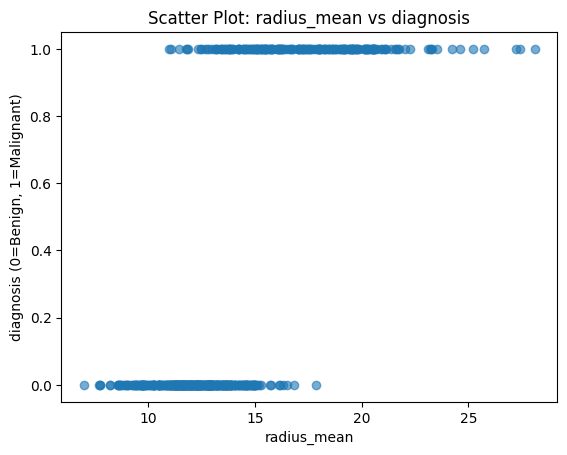

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: radius_mean vs diagnosis
plt.scatter(df['radius_mean'], df['diagnosis_num'], alpha=0.6)
plt.xlabel('radius_mean')
plt.ylabel('diagnosis (0=Benign, 1=Malignant)')
plt.title('Scatter Plot: radius_mean vs diagnosis')
plt.show()




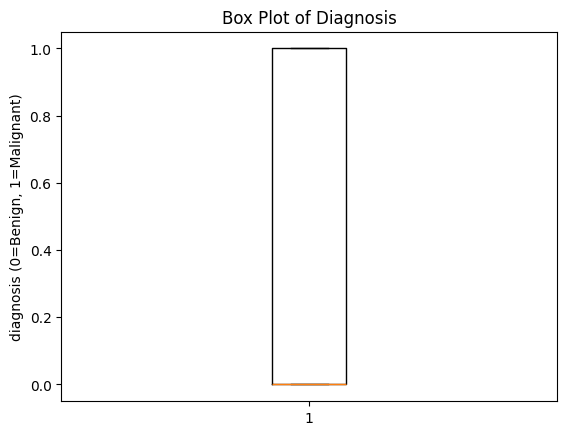

In [5]:
# Box plot
plt.boxplot(df['diagnosis_num'])
plt.ylabel('diagnosis (0=Benign, 1=Malignant)')
plt.title('Box Plot of Diagnosis')
plt.show()



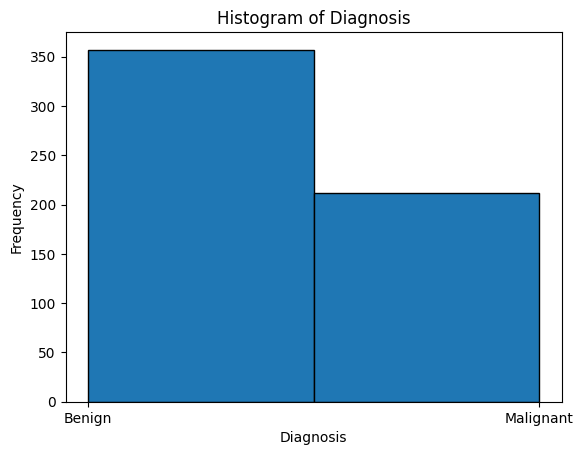

In [6]:
# Histogram
plt.hist(df['diagnosis_num'], bins=2, edgecolor='black')
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.xlabel('Diagnosis')
plt.ylabel('Frequency')
plt.title('Histogram of Diagnosis')
plt.show()



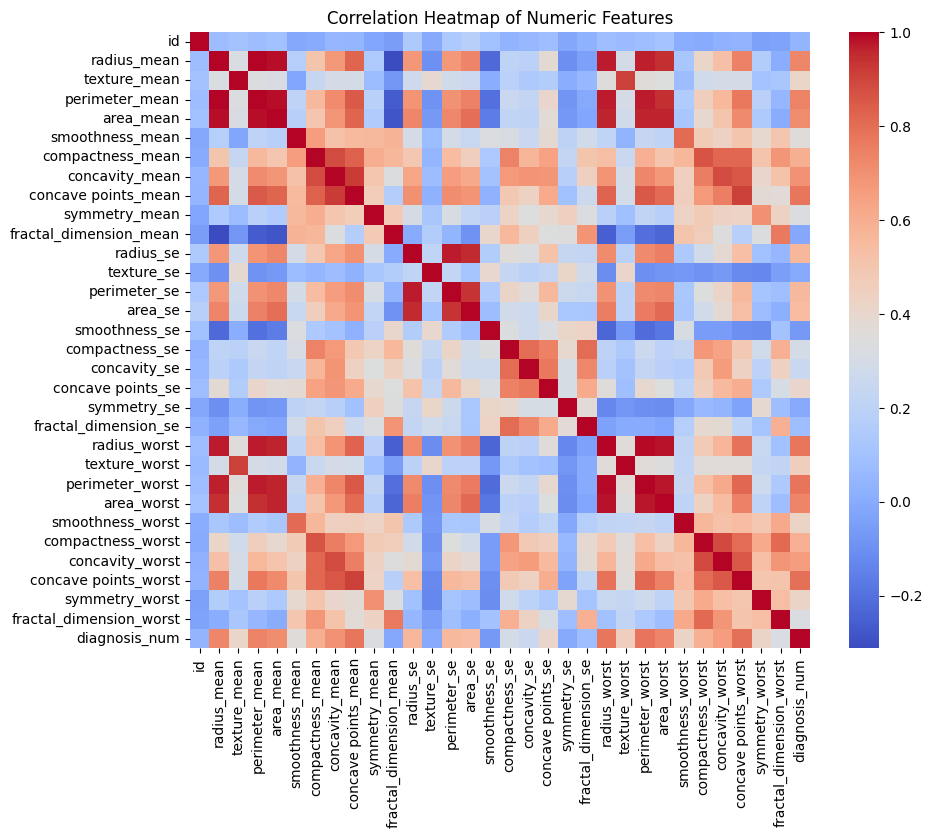

In [7]:
# Heatmap
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [8]:
from scipy.stats import pearsonr

pearson_r, pearson_p = pearsonr(df['radius_mean'], df['diagnosis_num'])
print(pearson_r, pearson_p)


0.7300285113754563 8.465940572264092e-96


In [9]:
from scipy.stats import spearmanr

spearman_r, spearman_p = spearmanr(df['radius_mean'], df['diagnosis_num'])
print(spearman_r, spearman_p)


0.7327849896210553 7.219245917007412e-97


In [10]:
import numpy as np
from scipy.stats import chi2_contingency

df['radius_cat'] = np.where(df['radius_mean'] > df['radius_mean'].mean(), 'High', 'Low')

contingency = pd.crosstab(df['radius_cat'], df['diagnosis'])
chi2, chi_p, dof, expected = chi2_contingency(contingency)
print(chi2, chi_p)


285.1548245576083 5.653357074691983e-64


In [11]:
from scipy.stats import ttest_1samp

population_mean = df['diagnosis_num'].mean()
sample_vals = random_sample['diagnosis_num']

t_stat, p_val = ttest_1samp(sample_vals, population_mean)
print(t_stat, p_val)


0.3530022105609316 0.7245856783929023
